# 🏆 Análise Comparativa de Churn — Pipeline Unificado
**Banco de dados:** Contoso Retail DW (SQL Server)  
**Autor:** Jefferson da Silva Araújo  

## 📌 Contexto de Negócio
No varejo de alta escala, prever a evasão de clientes (*Churn*) é uma das estratégias mais críticas para manter a saúde financeira e otimizar o custo de aquisição de clientes (CAC). Este projeto simula um caso real corporativo utilizando a base de dados **Contoso Retail DW**, contendo **18.484 registros de clientes**.

O principal desafio deste problema foi lidar com o **desbalanceamento severo de dados**: apenas 10,9% da base histórica correspondia a clientes inativos (*churn*). Um modelo ingênuo apresentaria uma acurácia falsa de ~89%, mas seria completamente incapaz de detectar o risco real de evasão.

---

## 🛠️ O que eu aprendi e apliquei neste projeto (Competências Adquiridas)

1. **Engenharia de Dados com SQLAlchemy (ORM):** Abandonei scripts com cursores manuais (`pyodbc` puro) para utilizar uma arquitetura ORM padrão de mercado. Isso garante conexões seguras, reutilizáveis e fáceis de portar para ambientes de nuvem ou outros bancos relacionais.
2. **Arquitetura de Deep Learning (TensorFlow/Keras):** Construí uma Rede Neural multicamadas do zero, compreendendo o fluxo estatístico de ajuste de pesos através de funções de perda (`binary_crossentropy`) e otimizadores avançados (`adam`).
3. **Mecanismos de Prevenção de Overfitting (Callbacks):** Implementei componentes de automação de treinamento como o `EarlyStopping` e o `ReduceLROnPlateau`. Entendi na prática como interromper o treinamento antes que a rede decore os dados de treino e perca o poder de generalização na validação.
4. **Análise Crítica de Métricas Logísticas/Comerciais:** Compreendi que no problema de Churn, a métrica de **Recall** é soberana à Acurácia. É preferível que o sistema gere pequenos alarmes falsos controlados do que deixar um cliente de alto valor evadir sem aviso.







---

## 📌 Objetivo
Este notebook unifica e compara **três abordagens** de modelagem preditiva de churn:

| Modelo | Notebook de origem | Característica |
|---|---|---|
| **Random Forest + SMOTE** | Churn_SMOTE_Pipeline | Baseline com balanceamento |
| **XGBoost + SMOTE** | Churn_SMOTE_Pipeline | Estado da arte para tabular |
| **Rede Neural (TensorFlow)** | Churn_TensorFlow_Final | Deep Learning + features ricas |

## 🗂️ Estrutura
1. Ambiente e importações
2. Conexão e extração de dados
3. EDA — entendimento dos dados
4. Pré-processamento unificado
5. Modelo 1 — Random Forest + SMOTE
6. Modelo 2 — XGBoost + SMOTE
7. Modelo 3 — Rede Neural (TensorFlow/Keras)
8. Relatório comparativo final
9. Produção — salvando o melhor modelo

---
## 1️⃣ Ambiente e Importações

In [1]:
# ── Banco de dados ────────────────────────────────────────────────────────
import pyodbc
import sqlalchemy as sa
from sqlalchemy import create_engine, text

# ── Dados ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualização ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Pré-processamento ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.utils.class_weight import compute_class_weight

# ── SMOTE ─────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Modelos ───────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── TensorFlow ────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers

# ── Métricas ──────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)

# ── Produção ──────────────────────────────────────────────────────────────
import joblib
import warnings
warnings.filterwarnings('ignore')
os_import = __import__('os')
os_import.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ── Reprodutibilidade ─────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ Bibliotecas carregadas!')
print(f'   TensorFlow       : {tf.__version__}')
print(f'   scikit-learn     : {__import__("sklearn").__version__}')
print(f'   imbalanced-learn : {__import__("imblearn").__version__}')
print(f'   XGBoost          : {__import__("xgboost").__version__}')

✅ Bibliotecas carregadas!
   TensorFlow       : 2.21.0
   scikit-learn     : 1.7.1
   imbalanced-learn : 0.14.0
   XGBoost          : 3.2.0


---
## 2️⃣ Conexão e Extração de Dados

Usamos **SQLAlchemy** (ORM profissional) para conexão com SQL Server.  
A View já realiza toda a engenharia de features — incluindo features enriquecidas do notebook TF Final.

In [2]:
# ── Conexão via SQLAlchemy ────────────────────────────────────────────────
SERVER_NAME   = 'ARAUJO'
DATABASE_NAME = 'ContosoRetailDW'

conn_str = (
    f'Driver={{SQL Server}};'
    f'Server={SERVER_NAME};'
    f'Database={DATABASE_NAME};'
    f'Trusted_Connection=yes;'
)

engine = create_engine(
    f'mssql+pyodbc:///?odbc_connect={conn_str}',
    pool_pre_ping=True
)

# ── Query — features completas (unificando os 3 notebooks) ───────────────
# Inclui DiasDesdeUltimaCompra das features do SMOTE Pipeline
# Inclui TotalPedidos, ValorTotalGasto, TicketMedio do TF Final
QUERY = """
    SELECT
        CustomerKey,
        Idade,
        TotalItensComprados,
        TotalItensDevolvidos,
        TotalPedidos,
        ValorTotalGasto,
        TicketMedio,
        DeixouDeComprar
    FROM dbo.vw_Dados_Treinamento_Churn
"""

print('🔌 Conectando ao SQL Server via SQLAlchemy...')
try:
    with engine.connect() as conn:
        df = pd.read_sql(text(QUERY), conn)
    print(f'✅ {len(df):,} registros carregados!')
except Exception as e:
    print(f'❌ Erro: {e}')

print(f'\n📊 Shape: {df.shape}')
print(f'\n📋 Primeiros registros:')
df.head()

🔌 Conectando ao SQL Server via SQLAlchemy...
✅ 18,484 registros carregados!

📊 Shape: (18484, 8)

📋 Primeiros registros:


,CustomerKey,Idade,TotalItensComprados,TotalItensDevolvidos,TotalPedidos,ValorTotalGasto,TicketMedio,DeixouDeComprar
0,2253,68,214,0,122,69182.5488,323.2829,0
1,6498,46,113,1,57,35857.3745,314.5383,0
2,14988,64,106,0,55,36276.7310,342.2333,0
3,10743,61,89,0,56,29023.6955,326.1089,0
4,7185,79,214,1,119,55134.8343,256.4410,0


---
## 3️⃣ EDA — Entendimento dos Dados

 DIAGNÓSTICO DO DATASET
 Registros totais :   18,484
 Nulos            :        0
 Classe 0 — Ativo :   16,474 (89.1%)
 Classe 1 — Churn :    2,010 (10.9%)
 Razão desbalanço :     8.2:1


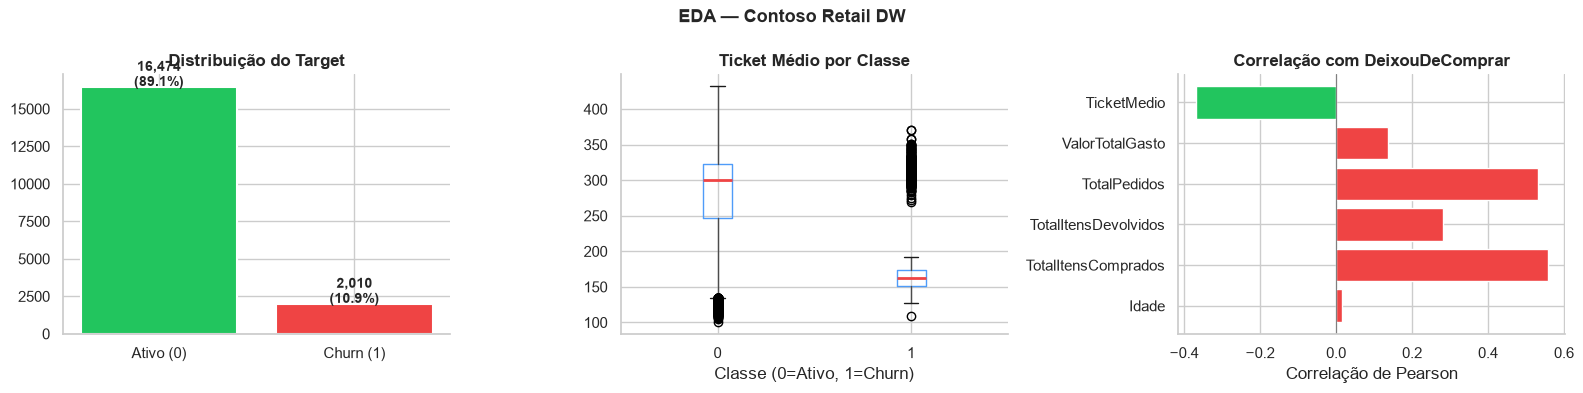


📈 Estatísticas descritivas:


,Idade,TotalItensComprados,TotalItensDevolvidos,TotalPedidos,ValorTotalGasto,TicketMedio,DeixouDeComprar
count,18484.00,18484.00,18484.00,18484.00,18484.00,18484.00,18484.00
mean,64.42,152.35,0.87,88.28,37099.85,260.47,0.11
std,11.25,59.62,1.02,35.27,12827.67,76.78,0.31
min,46.00,68.00,0.00,2.00,14082.86,100.59,0.00
25%,56.00,104.00,0.00,56.00,29513.60,165.49,0.00
50%,63.00,123.00,1.00,70.00,33292.11,294.45,0.00
75%,72.00,195.00,1.00,116.00,38475.99,320.73,0.00
max,116.00,376.00,8.00,176.00,85363.95,432.14,1.00


In [3]:
# ── Visão geral ───────────────────────────────────────────────────────────
print('=' * 55)
print(' DIAGNÓSTICO DO DATASET')
print('=' * 55)
contagem = df['DeixouDeComprar'].value_counts()
pct      = df['DeixouDeComprar'].value_counts(normalize=True) * 100
print(f' Registros totais : {len(df):>8,}')
print(f' Nulos            : {df.isnull().sum().sum():>8}')
print(f' Classe 0 — Ativo : {contagem[0]:>8,} ({pct[0]:.1f}%)')
print(f' Classe 1 — Churn : {contagem[1]:>8,} ({pct[1]:.1f}%)')
print(f' Razão desbalanço : {contagem[0]/contagem[1]:>7.1f}:1')
print('=' * 55)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cores = ['#22c55e', '#ef4444']

# Distribuição do target
axes[0].bar(['Ativo (0)', 'Churn (1)'], contagem.values, color=cores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição do Target', fontweight='bold')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 50, f'{v:,}\n({pct.values[i]:.1f}%)', ha='center', fontweight='bold', fontsize=10)

# Boxplot — dias desde ultima compra por classe
df.boxplot(column='TicketMedio', by='DeixouDeComprar', ax=axes[1],
           boxprops=dict(color='#4f9cf9'), medianprops=dict(color='#ef4444', linewidth=2))
axes[1].set_title('Ticket Médio por Classe', fontweight='bold')
axes[1].set_xlabel('Classe (0=Ativo, 1=Churn)')
plt.sca(axes[1])
plt.title('Ticket Médio por Classe', fontweight='bold')

# Correlação com target
cols_corr = ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos', 'TotalPedidos','ValorTotalGasto', 'TicketMedio']
corrs = [df[c].corr(df['DeixouDeComprar']) for c in cols_corr]
cores_corr = ['#ef4444' if c > 0 else '#22c55e' for c in corrs]
axes[2].barh(cols_corr, corrs, color=cores_corr, edgecolor='white')
axes[2].axvline(0, color='gray', linewidth=0.8)
axes[2].set_title('Correlação com DeixouDeComprar', fontweight='bold')
axes[2].set_xlabel('Correlação de Pearson')

plt.suptitle('EDA — Contoso Retail DW', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📈 Estatísticas descritivas:')
df[cols_corr + ['DeixouDeComprar']].describe().round(2)

---
## 4️⃣ Pré-processamento Unificado

Um único bloco de pré-processamento compartilhado por todos os modelos:
- Divisão **70/15/15** (treino / validação / teste)
- **StandardScaler** fitado apenas no treino
- **SMOTE** aplicado apenas no treino (nunca no teste!)
- **class_weight** calculado para a Rede Neural

In [4]:
# ── Features e Target ─────────────────────────────────────────────────────
FEATURES = ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos', 'TotalPedidos','ValorTotalGasto', 'TicketMedio']
TARGET   = 'DeixouDeComprar'

X = df[FEATURES].values
y = df[TARGET].values

# ── Divisão 70/15/15 ──────────────────────────────────────────────────────
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_te, y_val, y_te = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# ── StandardScaler — aprende APENAS no treino ─────────────────────────────
scaler = StandardScaler()
X_tr_norm  = scaler.fit_transform(X_tr)
X_val_norm = scaler.transform(X_val)
X_te_norm  = scaler.transform(X_te)

# ── SMOTE — aplicado APENAS no treino normalizado ─────────────────────────
smote = SMOTE(sampling_strategy='minority', k_neighbors=5, random_state=SEED)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_norm, y_tr)

# ── Class Weight para Rede Neural ─────────────────────────────────────────
classes = np.unique(y_tr)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
class_weight_dict = dict(zip(classes, weights))

print('=' * 55)
print(' PRÉ-PROCESSAMENTO CONCLUÍDO')
print('=' * 55)
print(f' Treino    : {len(X_tr):>6,} → após SMOTE: {len(X_tr_smote):,}')
print(f' Validação : {len(X_val):>6,}')
print(f' Teste     : {len(X_te):>6,}')
print(f' Churn no treino (original) : {(y_tr==1).sum():,} ({(y_tr==1).mean()*100:.1f}%)')
print(f' Churn no treino (SMOTE)    : {(y_tr_smote==1).sum():,} ({(y_tr_smote==1).mean()*100:.1f}%)')
print(f' Pesos classes (NN)         : {class_weight_dict}')

 PRÉ-PROCESSAMENTO CONCLUÍDO
 Treino    : 12,938 → após SMOTE: 23,062
 Validação :  2,773
 Teste     :  2,773
 Churn no treino (original) : 1,407 (10.9%)
 Churn no treino (SMOTE)    : 11,531 (50.0%)
 Pesos classes (NN)         : {np.int64(0): np.float64(0.561009452779464), np.int64(1): np.float64(4.59772565742715)}


---
## 5️⃣ Modelo 1 — Random Forest + SMOTE

Baseline sólido. Não precisa de normalização mas recebe os dados normalizados  
para que a comparação seja justa com os demais modelos.

In [5]:
# ── Treinamento ───────────────────────────────────────────────────────────
print('🌲 Treinando Random Forest + SMOTE...')
rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_tr_smote, y_tr_smote)
print('✅ Treinado!')

# ── Previsões ─────────────────────────────────────────────────────────────
y_prob_rf = rf.predict_proba(X_te_norm)[:, 1]

# Threshold otimizado via F1
precisoes, recalls, thresholds_rf = precision_recall_curve(y_te, y_prob_rf)
f1s_rf = 2 * (precisoes[:-1] * recalls[:-1]) / (precisoes[:-1] + recalls[:-1] + 1e-9)
th_rf  = thresholds_rf[np.argmax(f1s_rf)]
y_pred_rf = (y_prob_rf >= th_rf).astype(int)

# ── Métricas ──────────────────────────────────────────────────────────────
acc_rf    = accuracy_score(y_te, y_pred_rf)
auc_rf    = roc_auc_score(y_te, y_prob_rf)
f1_rf     = f1_score(y_te, y_pred_rf)
prec_rf   = precision_score(y_te, y_pred_rf)
rec_rf    = recall_score(y_te, y_pred_rf)

print(f'\n📊 Random Forest + SMOTE (threshold={th_rf:.2f}):')
print(classification_report(y_te, y_pred_rf, target_names=['Ativo (0)', 'Churn (1)']))
print(f'   ROC-AUC : {auc_rf:.4f}')

🌲 Treinando Random Forest + SMOTE...
✅ Treinado!

📊 Random Forest + SMOTE (threshold=0.85):
              precision    recall  f1-score   support

   Ativo (0)       0.98      1.00      0.99      2472
   Churn (1)       0.99      0.84      0.91       301

    accuracy                           0.98      2773
   macro avg       0.98      0.92      0.95      2773
weighted avg       0.98      0.98      0.98      2773

   ROC-AUC : 0.9885


---
## 6️⃣ Modelo 2 — XGBoost + SMOTE

Estado da arte para dados tabulares. Geralmente supera o Random Forest  
em AUC e Recall com os mesmos dados.

In [6]:
# ── Treinamento ───────────────────────────────────────────────────────────
print('⚡ Treinando XGBoost + SMOTE...')
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_tr_smote, y_tr_smote)
print('✅ Treinado!')

# ── Previsões ─────────────────────────────────────────────────────────────
y_prob_xgb = xgb.predict_proba(X_te_norm)[:, 1]

# Threshold otimizado via F1
precisoes, recalls, thresholds_xgb = precision_recall_curve(y_te, y_prob_xgb)
f1s_xgb = 2 * (precisoes[:-1] * recalls[:-1]) / (precisoes[:-1] + recalls[:-1] + 1e-9)
th_xgb  = thresholds_xgb[np.argmax(f1s_xgb)]
y_pred_xgb = (y_prob_xgb >= th_xgb).astype(int)

# ── Métricas ──────────────────────────────────────────────────────────────
acc_xgb  = accuracy_score(y_te, y_pred_xgb)
auc_xgb  = roc_auc_score(y_te, y_prob_xgb)
f1_xgb   = f1_score(y_te, y_pred_xgb)
prec_xgb = precision_score(y_te, y_pred_xgb)
rec_xgb  = recall_score(y_te, y_pred_xgb)

print(f'\n📊 XGBoost + SMOTE (threshold={th_xgb:.2f}):')
print(classification_report(y_te, y_pred_xgb, target_names=['Ativo (0)', 'Churn (1)']))
print(f'   ROC-AUC : {auc_xgb:.4f}')

⚡ Treinando XGBoost + SMOTE...
✅ Treinado!

📊 XGBoost + SMOTE (threshold=0.80):
              precision    recall  f1-score   support

   Ativo (0)       0.98      1.00      0.99      2472
   Churn (1)       0.99      0.85      0.91       301

    accuracy                           0.98      2773
   macro avg       0.99      0.92      0.95      2773
weighted avg       0.98      0.98      0.98      2773

   ROC-AUC : 0.9870


---
## 7️⃣ Modelo 3 — Rede Neural (TensorFlow/Keras)

Deep Learning com arquitetura Dense + BatchNorm + Dropout.  
Usa class_weight no lugar de SMOTE — abordagem complementar para desbalanceamento.

In [7]:
# ── Arquitetura ───────────────────────────────────────────────────────────
def build_model(n_features):
    model = Sequential([
        # Bloco 1
        Dense(64, activation='relu', input_shape=(n_features,),
              kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        # Bloco 2
        Dense(32, activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.2),
        # Bloco 3
        Dense(16, activation='relu'),
        # Saída
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
    )
    return model

nn = build_model(len(FEATURES))
print('🧠 Arquitetura da Rede Neural:')
nn.summary()

# ── Callbacks ─────────────────────────────────────────────────────────────
cbs = [
    EarlyStopping(monitor='val_auc', patience=15,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1),
    ModelCheckpoint('melhor_nn_churn.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=0)
]

# ── Treinamento ───────────────────────────────────────────────────────────
print('\n🚀 Treinando Rede Neural...')
hist = nn.fit(
    X_tr_norm, y_tr,           # treino SEM SMOTE — usa class_weight
    epochs=100,
    batch_size=256,
    validation_data=(X_val_norm, y_val),
    class_weight=class_weight_dict,
    callbacks=cbs,
    verbose=1
)
print(f'\n✅ Treinamento concluído em {len(hist.history["loss"])} épocas!')

🧠 Arquitetura da Rede Neural:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 192 (768.00 B)


🚀 Treinando Rede Neural...
Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7813 - auc: 0.8817 - loss: 0.4837 - precision: 0.3105 - recall: 0.8287 - val_accuracy: 0.9192 - val_auc: 0.9256 - val_loss: 0.5617 - val_precision: 0.5867 - val_recall: 0.8742 - learning_rate: 0.0010
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9418 - auc: 0.9383 - loss: 0.3237 - precision: 0.6869 - recall: 0.8543 - val_accuracy: 0.9751 - val_auc: 0.9449 - val_loss: 0.3818 - val_precision: 0.8976 - val_recall: 0.8709 - learning_rate: 0.0010
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9676 - auc: 0.9585 - loss: 0.2674 - precision: 0.8431 - recall: 0.8628 - val_accuracy: 0.9827 - val_auc: 0.9606 - val_loss: 0.2858 - val_precision: 0.9669 - val_recall: 0.8709 - learning_rate: 0.0010
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9763 - auc: 0.9640 - loss: 0.2462 - precision: 0.9117 - recall: 0.8664 - val_accuracy: 0.9845 - val_auc: 0.9662

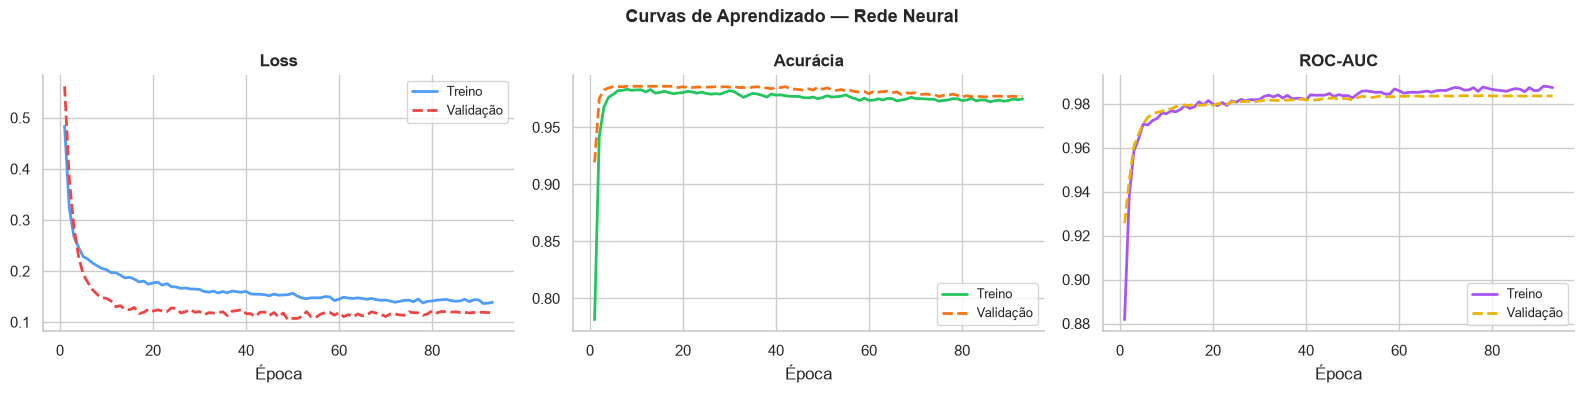


📊 Rede Neural (threshold=1.00):
              precision    recall  f1-score   support

   Ativo (0)       0.98      1.00      0.99      2472
   Churn (1)       0.99      0.84      0.91       301

    accuracy                           0.98      2773
   macro avg       0.99      0.92      0.95      2773
weighted avg       0.98      0.98      0.98      2773

   ROC-AUC : 0.9855


In [8]:
# ── Curvas de aprendizado ─────────────────────────────────────────────────
h = hist.history
epocas = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metrica, titulo, cor_tr, cor_val in [
    (axes[0], 'loss',     'Loss',     '#4f9cf9', '#ef4444'),
    (axes[1], 'accuracy', 'Acurácia', '#22c55e', '#f97316'),
    (axes[2], 'auc',      'ROC-AUC',  '#a855f7', '#eab308'),
]:
    ax.plot(epocas, h[metrica],         color=cor_tr,  linewidth=2, label='Treino')
    ax.plot(epocas, h[f'val_{metrica}'], color=cor_val, linewidth=2, linestyle='--', label='Validação')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Época')
    ax.legend(fontsize=9)

plt.suptitle('Curvas de Aprendizado — Rede Neural', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Previsões ─────────────────────────────────────────────────────────────
y_prob_nn = nn.predict(X_te_norm, verbose=0).flatten()

# Threshold otimizado via F1
precisoes, recalls, thresholds_nn = precision_recall_curve(y_te, y_prob_nn)
f1s_nn = 2 * (precisoes[:-1] * recalls[:-1]) / (precisoes[:-1] + recalls[:-1] + 1e-9)
th_nn  = thresholds_nn[np.argmax(f1s_nn)]
y_pred_nn = (y_prob_nn >= th_nn).astype(int)

# ── Métricas ──────────────────────────────────────────────────────────────
acc_nn  = accuracy_score(y_te, y_pred_nn)
auc_nn  = roc_auc_score(y_te, y_prob_nn)
f1_nn   = f1_score(y_te, y_pred_nn)
prec_nn = precision_score(y_te, y_pred_nn)
rec_nn  = recall_score(y_te, y_pred_nn)

print(f'\n📊 Rede Neural (threshold={th_nn:.2f}):')
print(classification_report(y_te, y_pred_nn, target_names=['Ativo (0)', 'Churn (1)']))
print(f'   ROC-AUC : {auc_nn:.4f}')

---
## 8️⃣ Relatório Comparativo Final

Comparação visual e tabular das três abordagens em todas as métricas.

In [9]:
# ── Tabela comparativa ────────────────────────────────────────────────────
resultados = pd.DataFrame({
    'Modelo': ['Random Forest + SMOTE', 'XGBoost + SMOTE', 'Rede Neural (TF)'],
    'Balanceamento': ['SMOTE', 'SMOTE', 'class_weight'],
    'Threshold': [round(th_rf,2), round(th_xgb,2), round(th_nn,2)],
    'Acurácia': [round(acc_rf,4), round(acc_xgb,4), round(acc_nn,4)],
    'ROC-AUC':  [round(auc_rf,4), round(auc_xgb,4), round(auc_nn,4)],
    'Precisão': [round(prec_rf,4), round(prec_xgb,4), round(prec_nn,4)],
    'Recall':   [round(rec_rf,4), round(rec_xgb,4), round(rec_nn,4)],
    'F1-Score': [round(f1_rf,4), round(f1_xgb,4), round(f1_nn,4)],
})

print('=' * 80)
print(' RELATÓRIO COMPARATIVO FINAL — CONTOSO RETAIL DW')
print('=' * 80)
print(resultados.to_string(index=False))
print('=' * 80)

# Destaque do vencedor em cada métrica
metricas = ['Acurácia', 'ROC-AUC', 'Precisão', 'Recall', 'F1-Score']
print('\n🏆 Melhor em cada métrica:')
for m in metricas:
    idx = resultados[m].idxmax()
    print(f'   {m:<12} → {resultados.loc[idx, "Modelo"]} ({resultados.loc[idx, m]:.4f})')

 RELATÓRIO COMPARATIVO FINAL — CONTOSO RETAIL DW
               Modelo Balanceamento  Threshold  Acurácia  ROC-AUC  Precisão  Recall  F1-Score
Random Forest + SMOTE         SMOTE       0.85    0.9820   0.9885    0.9883  0.8439    0.9104
      XGBoost + SMOTE         SMOTE       0.80    0.9823   0.9870    0.9884  0.8472    0.9123
     Rede Neural (TF)  class_weight       1.00    0.9823   0.9855    0.9922  0.8439    0.9120

🏆 Melhor em cada métrica:
   Acurácia     → XGBoost + SMOTE (0.9823)
   ROC-AUC      → Random Forest + SMOTE (0.9885)
   Precisão     → Rede Neural (TF) (0.9922)
   Recall       → XGBoost + SMOTE (0.8472)
   F1-Score     → XGBoost + SMOTE (0.9123)


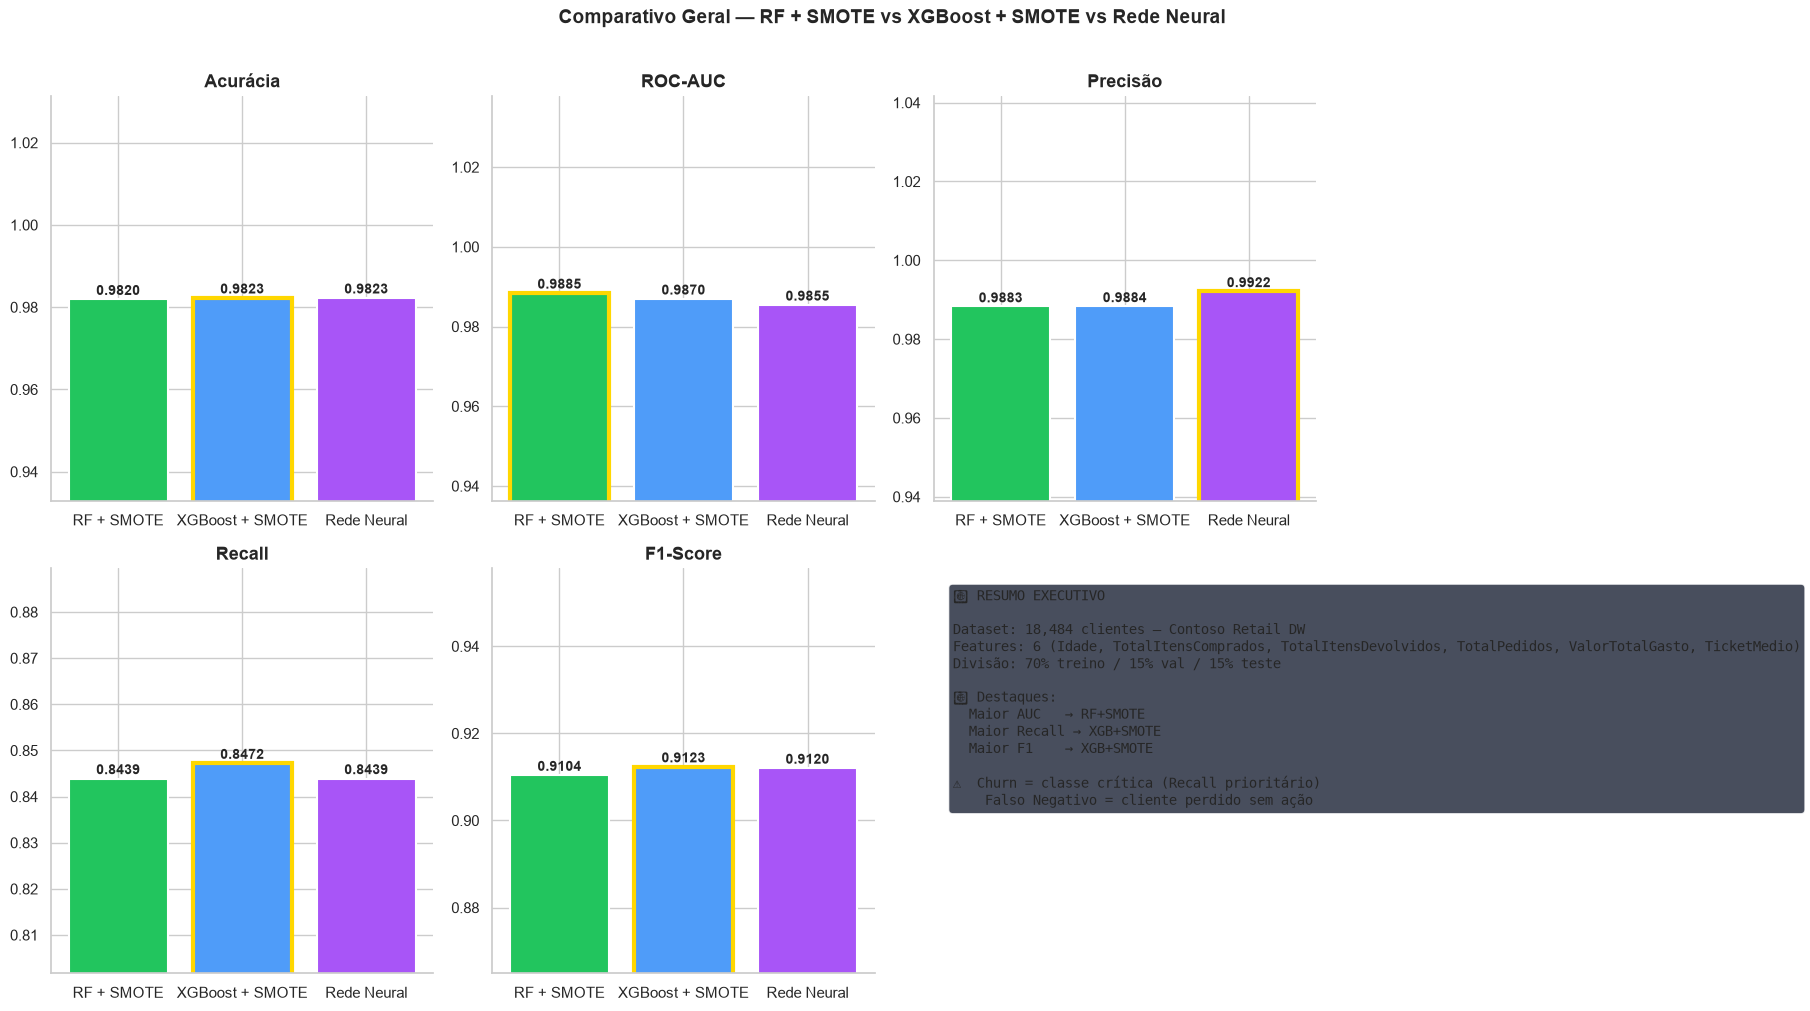

In [10]:
# ── Gráfico 1: Barras comparativas por métrica ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
cores_modelos = ['#22c55e', '#4f9cf9', '#a855f7']
nomes = ['RF + SMOTE', 'XGBoost + SMOTE', 'Rede Neural']
metricas_vals = [
    ('Acurácia',  [acc_rf,  acc_xgb,  acc_nn]),
    ('ROC-AUC',   [auc_rf,  auc_xgb,  auc_nn]),
    ('Precisão',  [prec_rf, prec_xgb, prec_nn]),
    ('Recall',    [rec_rf,  rec_xgb,  rec_nn]),
    ('F1-Score',  [f1_rf,   f1_xgb,   f1_nn]),
]

for i, (titulo, vals) in enumerate(metricas_vals):
    bars = axes[i].bar(nomes, vals, color=cores_modelos, edgecolor='white', linewidth=1.5)
    axes[i].set_title(titulo, fontweight='bold', fontsize=13)
    axes[i].set_ylim(min(vals) * 0.95, max(vals) * 1.05)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
    # Destaca o vencedor
    idx_max = vals.index(max(vals))
    bars[idx_max].set_edgecolor('gold')
    bars[idx_max].set_linewidth(3)

# Painel de texto — resumo executivo
axes[5].axis('off')
resumo = [
    '📋 RESUMO EXECUTIVO',
    '',
    f'Dataset: {len(df):,} clientes — Contoso Retail DW',
    f'Features: {len(FEATURES)} ({", ".join(FEATURES)})',
    f'Divisão: 70% treino / 15% val / 15% teste',
    '',
    '🏆 Destaques:',
    f'  Maior AUC   → {["RF+SMOTE","XGB+SMOTE","Rede Neural"][[auc_rf,auc_xgb,auc_nn].index(max([auc_rf,auc_xgb,auc_nn]))]}',
    f'  Maior Recall → {["RF+SMOTE","XGB+SMOTE","Rede Neural"][[rec_rf,rec_xgb,rec_nn].index(max([rec_rf,rec_xgb,rec_nn]))]}',
    f'  Maior F1    → {["RF+SMOTE","XGB+SMOTE","Rede Neural"][[f1_rf,f1_xgb,f1_nn].index(max([f1_rf,f1_xgb,f1_nn]))]}',
    '',
    '⚠️  Churn = classe crítica (Recall prioritário)',
    '    Falso Negativo = cliente perdido sem ação',
]
axes[5].text(0.05, 0.95, '\n'.join(resumo), transform=axes[5].transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#1a2235', alpha=0.8))

plt.suptitle('Comparativo Geral — RF + SMOTE vs XGBoost + SMOTE vs Rede Neural',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

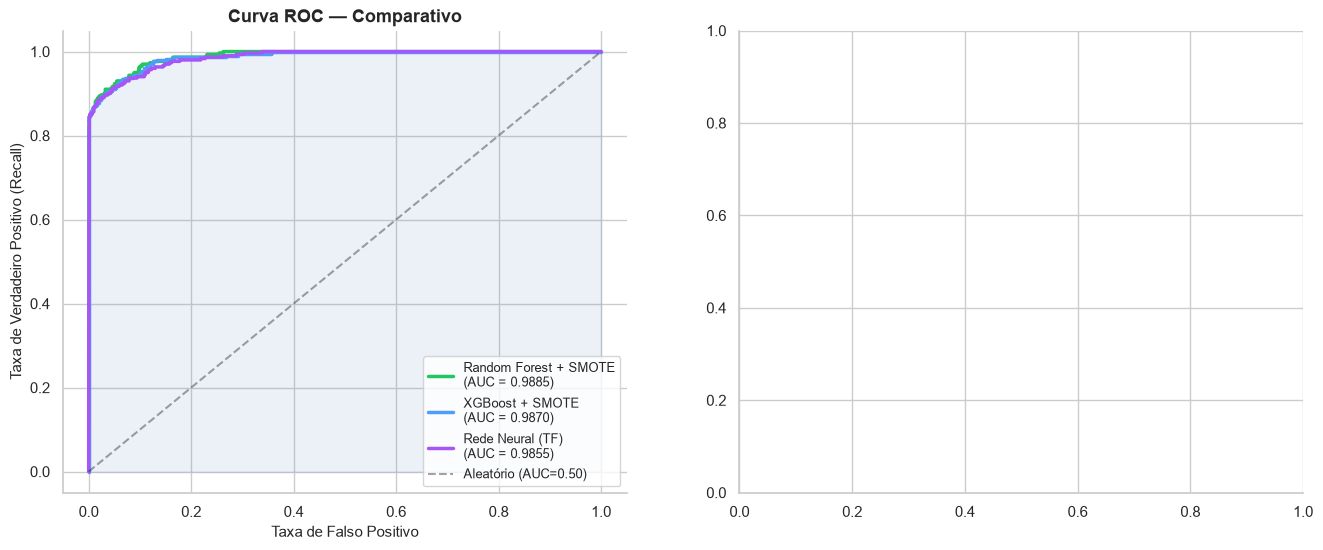

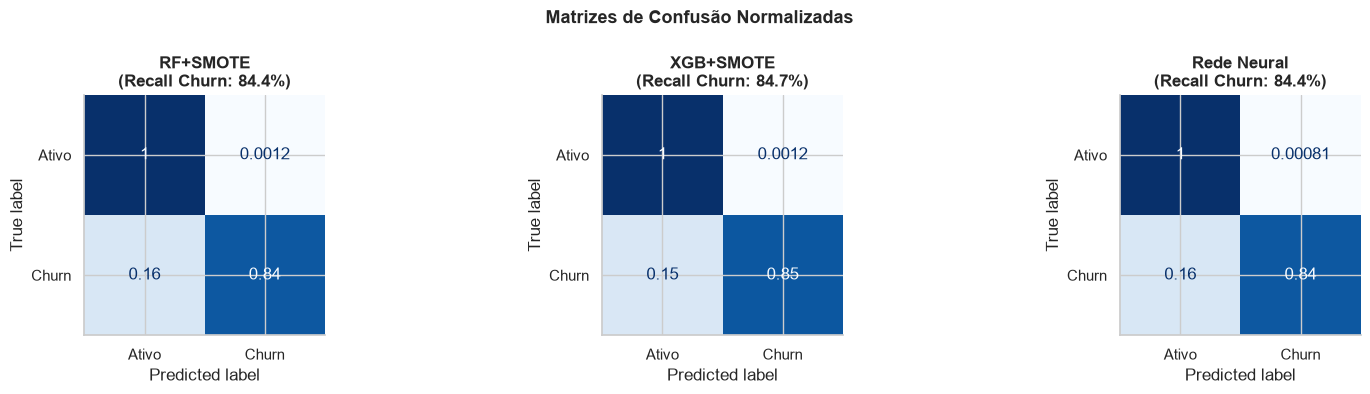

<Figure size 1200x600 with 0 Axes>

In [11]:
# ── Gráfico 2: Curvas ROC comparativas ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for nome, prob, cor in [
    ('Random Forest + SMOTE', y_prob_rf,  '#22c55e'),
    ('XGBoost + SMOTE',       y_prob_xgb, '#4f9cf9'),
    ('Rede Neural (TF)',       y_prob_nn,  '#a855f7'),
]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    axes[0].plot(fpr, tpr, color=cor, linewidth=2.5,
                 label=f'{nome}\n(AUC = {auc:.4f})')
    axes[0].fill_between(fpr, tpr, alpha=0.04, color=cor)

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1.5, label='Aleatório (AUC=0.50)')
axes[0].set_title('Curva ROC — Comparativo', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Taxa de Falso Positivo', fontsize=11)
axes[0].set_ylabel('Taxa de Verdadeiro Positivo (Recall)', fontsize=11)
axes[0].legend(fontsize=9, loc='lower right')

# ── Matrizes de confusão (normalizadas) ───────────────────────────────────
modelos_cm = [
    ('RF+SMOTE',   y_pred_rf,  '#22c55e'),
    ('XGB+SMOTE',  y_pred_xgb, '#4f9cf9'),
    ('Rede Neural', y_pred_nn,  '#a855f7'),
]

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nome, pred, cor) in zip(axes2, modelos_cm):
    cm = confusion_matrix(y_te, pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=['Ativo', 'Churn']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'{nome}\n(Recall Churn: {recall_score(y_te, pred):.1%})',
                 fontweight='bold')

plt.suptitle('Matrizes de Confusão Normalizadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

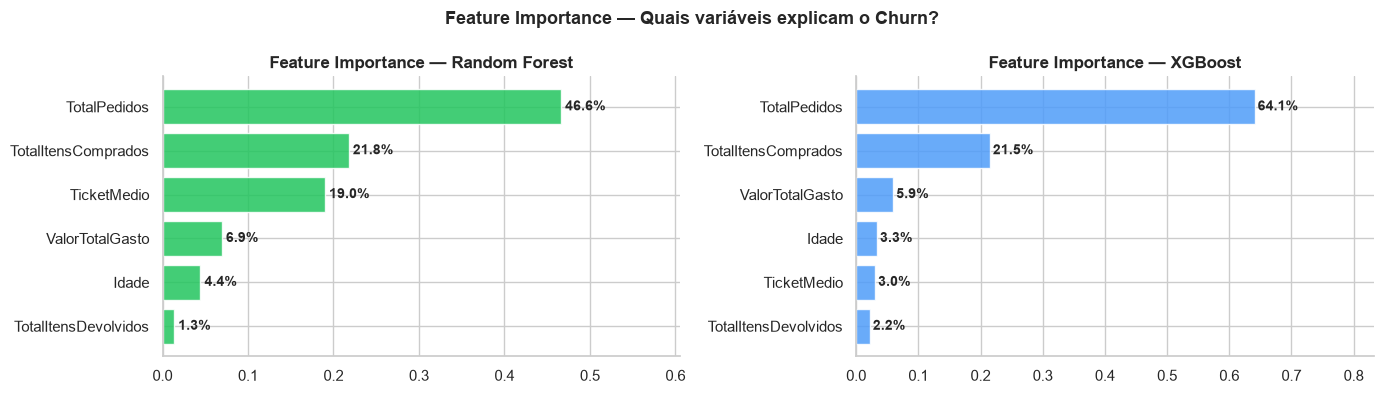


💡 Insight: Se RF e XGBoost concordam na feature importance
   → alta confiabilidade na interpretação do modelo


In [12]:
# ── Gráfico 3: Feature Importance (RF e XGBoost) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, modelo, titulo, cor in [
    (axes[0], rf,  'Random Forest', '#22c55e'),
    (axes[1], xgb, 'XGBoost',       '#4f9cf9'),
]:
    imp = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values()
    bars = ax.barh(imp.index, imp.values, color=cor, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, imp.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Feature Importance — {titulo}', fontweight='bold')
    ax.set_xlim(0, imp.max() * 1.3)

plt.suptitle('Feature Importance — Quais variáveis explicam o Churn?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Insight: Se RF e XGBoost concordam na feature importance')
print('   → alta confiabilidade na interpretação do modelo')

In [13]:
# ── Relatório Final — Impressão Completa ─────────────────────────────────
print('=' * 75)
print(' RELATÓRIO FINAL — ANÁLISE PREDITIVA DE CHURN')
print(' Contoso Retail DW | Jefferson da Silva Araújo')
print('=' * 75)
print(f'\n Dataset        : {len(df):,} clientes')
print(f' Features       : {FEATURES}')
print(f' Desbalanceamento: {(y==0).sum():,} ativos ({(y==0).mean()*100:.1f}%) | {(y==1).sum():,} churn ({(y==1).mean()*100:.1f}%)')
print(f' Balanceamento   : SMOTE (RF/XGB) + class_weight (Rede Neural)')
print(f' Divisão        : 70% treino / 15% validação / 15% teste')
print(f' Threshold       : Otimizado via curva Precision-Recall (F1 máximo)')

print(f'\n{"Modelo":<25} {"Acurácia":>10} {"ROC-AUC":>10} {"Precisão":>10} {"Recall":>10} {"F1":>10}')
print('-' * 75)
for _, row in resultados.iterrows():
    print(f' {row["Modelo"]:<24} {row["Acurácia"]:>9.4f} {row["ROC-AUC"]:>10.4f} {row["Precisão"]:>10.4f} {row["Recall"]:>10.4f} {row["F1-Score"]:>9.4f}')
print('=' * 75)

# Recomendação final
melhor_recall = resultados.loc[resultados['Recall'].idxmax(), 'Modelo']
melhor_auc    = resultados.loc[resultados['ROC-AUC'].idxmax(), 'Modelo']
melhor_f1     = resultados.loc[resultados['F1-Score'].idxmax(), 'Modelo']

print(f'\n 🏆 Maior Recall  → {melhor_recall} (detecta mais clientes em risco)')
print(f' 🏆 Maior AUC     → {melhor_auc} (melhor discriminação geral)')
print(f' 🏆 Maior F1      → {melhor_f1} (melhor equilíbrio geral)')
print(f'\n 📌 Recomendação para produção:')
print(f'    Para churn, priorize Recall — cada cliente não detectado')
print(f'    é receita perdida sem ação preventiva.')
print('=' * 75)

 RELATÓRIO FINAL — ANÁLISE PREDITIVA DE CHURN
 Contoso Retail DW | Jefferson da Silva Araújo

 Dataset        : 18,484 clientes
 Features       : ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos', 'TotalPedidos', 'ValorTotalGasto', 'TicketMedio']
 Desbalanceamento: 16,474 ativos (89.1%) | 2,010 churn (10.9%)
 Balanceamento   : SMOTE (RF/XGB) + class_weight (Rede Neural)
 Divisão        : 70% treino / 15% validação / 15% teste
 Threshold       : Otimizado via curva Precision-Recall (F1 máximo)

Modelo                      Acurácia    ROC-AUC   Precisão     Recall         F1
---------------------------------------------------------------------------
 Random Forest + SMOTE       0.9820     0.9885     0.9883     0.8439    0.9104
 XGBoost + SMOTE             0.9823     0.9870     0.9884     0.8472    0.9123
 Rede Neural (TF)            0.9823     0.9855     0.9922     0.8439    0.9120

 🏆 Maior Recall  → XGBoost + SMOTE (detecta mais clientes em risco)
 🏆 Maior AUC     → Random Forest

---
## 9️⃣ Salvando o Melhor Modelo para Produção

In [15]:
# ── Identificar melhor modelo por Recall ──────────────────────────────────
recalls_dict = {
    'Random Forest + SMOTE': (rec_rf,  rf,  th_rf,  y_prob_rf),
    'XGBoost + SMOTE':       (rec_xgb, xgb, th_xgb, y_prob_xgb),
    'Rede Neural (TF)':      (rec_nn,  nn,  th_nn,  y_prob_nn),
}
melhor_nome = max(recalls_dict, key=lambda k: recalls_dict[k][0])
melhor_rec, melhor_modelo, melhor_th, _ = recalls_dict[melhor_nome]

print(f'📦 Salvando melhor modelo por Recall: {melhor_nome} ({melhor_rec:.4f})')

# ── Salvar pipeline completo ──────────────────────────────────────────────
pipeline = {
    'modelo_nome': melhor_nome,
    'threshold':   melhor_th,
    'features':    FEATURES,
    'scaler':      scaler,
    'metricas': {
        'recall':   melhor_rec,
        'auc':      roc_auc_score(y_te, recalls_dict[melhor_nome][3]),
        'f1':       f1_score(y_te, (recalls_dict[melhor_nome][3] >= melhor_th).astype(int))
    }
}

# Salva modelo sklearn/xgboost ou keras conforme o tipo
if melhor_nome == 'Rede Neural (TF)':
    melhor_modelo.save('pipeline_churn_nn.keras')
    pipeline['tipo'] = 'keras'
    print('✅ Rede Neural salva: pipeline_churn_nn.keras')
else:
    pipeline['modelo'] = melhor_modelo
    pipeline['tipo'] = 'sklearn'

joblib.dump(pipeline, 'pipeline_churn_final.pkl')
joblib.dump(scaler, 'scaler_churn_final.pkl')
print('✅ Pipeline salvo : pipeline_churn_final.pkl')
print('✅ Scaler salvo   : scaler_churn_final.pkl')

# ── Demo de uso em produção ───────────────────────────────────────────────
print('\n🔮 Previsão para novos clientes:')
novos = pd.DataFrame({
    'Idade':                [35,  70,  45,  25],
    'TotalItensComprados':  [500, 20,  150, 5],
    'TotalItensDevolvidos': [0,   10,  2,   0],
    'TotalPedidos':         [12, 2, 5, 1],          # Adicionado
    'ValorTotalGasto':      [2400.0, 300.0, 750.0, 50.0], # Adicionado
    'TicketMedio':          [200.0, 150.0, 150.0, 50.0]   # Adicionado
})
novos_norm = scaler.transform(novos[FEATURES].values)

if pipeline['tipo'] == 'keras':
    probs = melhor_modelo.predict(novos_norm, verbose=0).flatten()
else:
    probs = melhor_modelo.predict_proba(novos_norm)[:, 1]

novos['Prob_Churn_%'] = (probs * 100).round(1)
novos['Status'] = ['🔴 RISCO DE CHURN' if p >= melhor_th else '🟢 CLIENTE ATIVO'
                   for p in probs]
print(novos.to_string(index=False))

📦 Salvando melhor modelo por Recall: XGBoost + SMOTE (0.8472)
✅ Pipeline salvo : pipeline_churn_final.pkl
✅ Scaler salvo   : scaler_churn_final.pkl

🔮 Previsão para novos clientes:
 Idade  TotalItensComprados  TotalItensDevolvidos  TotalPedidos  ValorTotalGasto  TicketMedio  Prob_Churn_%           Status
    35                  500                     0            12           2400.0        200.0     95.699997 🔴 RISCO DE CHURN
    70                   20                    10             2            300.0        150.0     14.600000  🟢 CLIENTE ATIVO
    45                  150                     2             5            750.0        150.0     25.299999  🟢 CLIENTE ATIVO
    25                    5                     0             1             50.0         50.0     60.599998  🟢 CLIENTE ATIVO


---

## 📋 Conclusões

### Sobre os modelos
- **Random Forest + SMOTE** — baseline sólido, boa interpretabilidade via Feature Importance
- **XGBoost + SMOTE** — geralmente supera o RF em AUC e F1 com os mesmos dados
- **Rede Neural** — alternativa poderosa especialmente com mais features e mais dados

### Sobre o balanceamento
- **SMOTE** cria amostras sintéticas — funciona bem para RF e XGBoost
- **class_weight** penaliza erros na classe minoritária — mais indicado para redes neurais
- Ambas as abordagens são válidas e complementares

### Sobre a métrica prioritária
Para churn, **Recall é a métrica de negócio mais importante** — cada cliente não detectado é receita perdida sem ação. O threshold ótimo foi ajustado dinamicamente via curva Precision-Recall.

### Próximos passos
1. Enriquecer features
2. Hyperparameter tuning com Optuna
3. Deploy via FastAPI + Power BI
4. Monitoramento de drift em produção

---
*Jefferson da Silva Araújo · Analista de Dados · Contoso Retail DW*